In [2]:
import pyspark.sql, pyspark.sql.functions
from pyspark.sql import SparkSession

# Стартиране на SparkSession 
spark = (
    SparkSession.builder
    .appName("Neural network example with SHAP")
    .master("local[*]")
    .getOrCreate()
)
print("SparkSession стартиран успешно")
print("Spark версия:", spark.version)

SparkSession стартиран успешно
Spark версия: 4.0.1


In [67]:
from sklearn.datasets import make_classification
import pandas as pd

# Генериране на синтетични данни
X, y = make_classification(
    n_samples=5000,      # брой записи
    n_features=4,        # брой характеристики
    n_informative=4,     # всички характеристики са информативни
    n_redundant=0,
    n_repeated=0,
    n_classes=6,         # 6 класа
    n_clusters_per_class=1,
    class_sep=2.5,       # разделимост между класовете
    random_state=42
)

# DataFrame
df = pd.DataFrame(X,
    columns=[
        "Age",
        "PlatformHours",
        "OutPlatformHours",
        "Self-Assessment"
    ]
)

# Целева променлива
df["Satisfaction"] = y

print(df.head())
print(df.shape)

        Age  PlatformHours  OutPlatformHours  Self-Assessment  Satisfaction
0  2.781909      -1.797719          2.403584         2.509160             4
1 -4.385868       1.262947         -1.185843        -2.824924             0
2 -3.203238       3.315156          1.507976         0.839395             5
3 -3.907329      -3.511030          0.900976        -1.525488             1
4  1.946108      -3.141883          1.292526         3.785777             4
(5000, 5)


In [68]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Подготовка на данните
feature_cols = ["Age","PlatformHours","OutPlatformHours","Self-assessment"]
# преобразуване към Spark DataFrame
spark_df = spark.createDataFrame(df)
# Обединяване на всички характеристики във features колона
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(spark_df)

# Разделяне на данните
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)

# Архитектура на мрежата
layers = [4, 10, 6]
# Създаване на модела
mlp = MultilayerPerceptronClassifier(
    featuresCol="features", labelCol="Satisfaction",
    layers=layers, maxIter=50, stepSize=0.001)
# Обучение
model = mlp.fit(train_data)

# Прогнозиране
predictions = model.transform(test_data)
# Оценка
evaluator = MulticlassClassificationEvaluator(
    labelCol="Satisfaction", predictionCol="prediction",
    metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9726848767488341


In [71]:
import pandas as pd
import numpy as np
import shap

# Преобразуване към pandas
train_pd = train_data.select("Age","PlatformHours","OutPlatformHours","Self-Assessment").toPandas()
test_pd = test_data.select( "Age","PlatformHours","OutPlatformHours","Self-Assessment").toPandas()
# Имена на характеристиките
feature_names = ["Age","PlatformHours","OutPlatformHours","Self-Assessment"]

# Функция за вероятности
def predict_proba_fn(x):
    pdf = pd.DataFrame(x,columns=feature_names    )
    spark_df = spark.createDataFrame(pdf)
    spark_df = assembler.transform(spark_df)
    predictions = model.transform(spark_df)
    return np.array(
        predictions.select("probability")
        .rdd
        .map(lambda row: row.probability.toArray())
        .collect()    )
# Проверка на вероятностите
probs = predict_proba_fn(test_pd.iloc[:5])

print(probs)
# Създаване на SHAP обяснител
explainer = shap.KernelExplainer(
    predict_proba_fn,
    train_pd.iloc[:20])
# Изчисляване на SHAP стойности
shap_values = explainer.shap_values(test_pd.iloc[:1])

# Визуализация
shap.initjs()
shap.force_plot(
    explainer.expected_value[0],
    shap_values[0][:,0],
    test_pd.iloc[0].values,
    feature_names=feature_names)

[[7.74074982e-01 1.38825023e-02 1.13951375e-04 1.89258128e-05
  1.64582005e-02 1.95451438e-01]
 [4.76964704e-02 9.30694525e-01 2.98125443e-03 8.86589788e-06
  1.09605403e-02 7.65834415e-03]
 [9.57500429e-01 6.79059205e-03 5.80091389e-05 1.23799130e-05
  4.58901753e-03 3.10495725e-02]
 [9.50896773e-02 8.82961708e-01 2.19366752e-03 1.05789242e-05
  1.20979974e-02 7.64637090e-03]
 [9.33783970e-01 3.91762900e-02 1.59165597e-03 1.72038981e-04
  5.41016337e-03 1.98658820e-02]]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:25<00:00, 25.41s/it]


In [7]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 8.9 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 39.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------ --------------------------------- 5.8/38.1 MB 27.0 MB/s eta 0:00:02
   ------------ --------------------------- 12.1/38.1 MB 28.0 MB/s eta 0:00:01
   ------------------- -------------------- 18.4/38.1 MB 28.9 MB/s eta 0:00:01
   -------------------------- ------------- 24.9/38.1 MB 29.7 MB/s eta 0:00:01
   -------------------------------- ------- 31.5/38.1 MB 30.2 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 30.6 M

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [09:27<00:00, 28.37s/it]


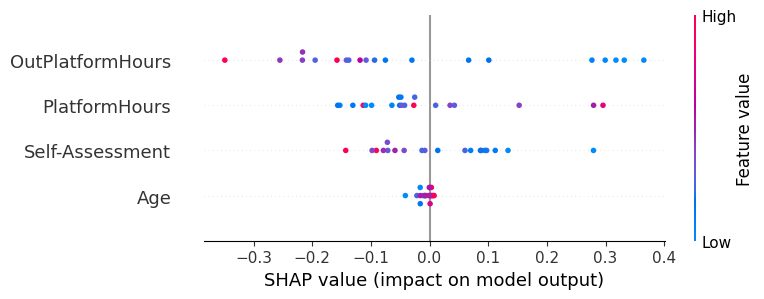

In [72]:
import pandas as pd
import numpy as np
import shap

# Преобразуване към pandas
train_pd = train_data.select("Age","PlatformHours","OutPlatformHours","Self-Assessment").toPandas()
test_pd = test_data.select( "Age","PlatformHours","OutPlatformHours","Self-Assessment").toPandas()
# Имена на характеристиките
feature_names = ["Age","PlatformHours","OutPlatformHours","Self-Assessment"]

# Функция за вероятности
def predict_proba_fn(x):
    pdf = pd.DataFrame(x,columns=feature_names    )
    spark_df = spark.createDataFrame(pdf)
    spark_df = assembler.transform(spark_df)
    predictions = model.transform(spark_df)
    return np.array(
        predictions.select("probability")
        .rdd
        .map(lambda row: row.probability.toArray())
        .collect()    )

# Създаване на SHAP обяснител
explainer = shap.KernelExplainer(
    predict_proba_fn,
    train_pd.iloc[:50])

# Изчисляване на SHAP стойности
shap_values = explainer.shap_values(test_pd.iloc[:20])

# Глобално обяснение
shap.summary_plot(
    shap_values[:, :, 0],
    test_pd.iloc[:20],
    feature_names=feature_names)

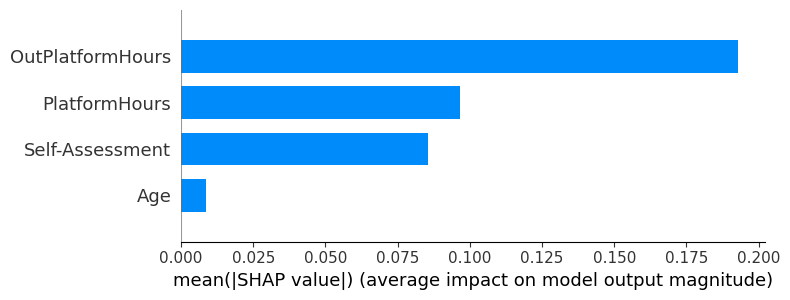

In [73]:
shap.summary_plot(
    shap_values[:, :, 0],
    test_pd.iloc[:20],
    feature_names=feature_names,
    plot_type="bar")